In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from indusense.ingestor import *

In [3]:
df = load_incidents("data/releves_incidents.csv")
df.head()

,incident_id,date,time,operator_name,machine_id,severity,operator_badge,comment,shift,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite
0,INC-000001,2025-06-01,05:42,Lucas Bernard,MACH-06,4,OP1002,chauffe anormale,nuit,1,0,0,0,0,0,0,0,0
1,INC-000002,2025-06-01,21:08,Hugo Thomas,MACH-15,3,OP1004,micro-fuite / baisse pression,apres-midi,0,1,0,0,0,0,0,0,0
2,INC-000003,2025-06-02,05:43,Lucas Bernard,MACH-10,2,OP1002,défaut capteur confirmé,nuit,0,0,0,0,0,0,1,0,0
3,INC-000004,2025-06-03,05:43,Sophie Leclerc,MACH-10,3,OP1006,signal capteur hors plage,nuit,0,0,0,0,0,0,1,0,0
4,INC-000005,2025-06-04,01:01,Marie Dupont,MACH-14,2,OP1001,alerte température haute,nuit,1,0,0,0,0,0,0,0,0


Ok, une fonction dans la lib pour "chaque" graphe

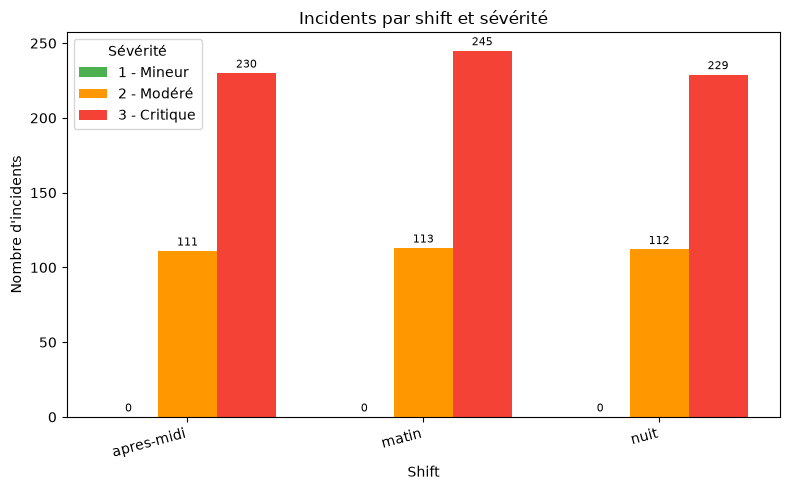

In [4]:
fig = incident_report_per_shift(df)
plt.show()

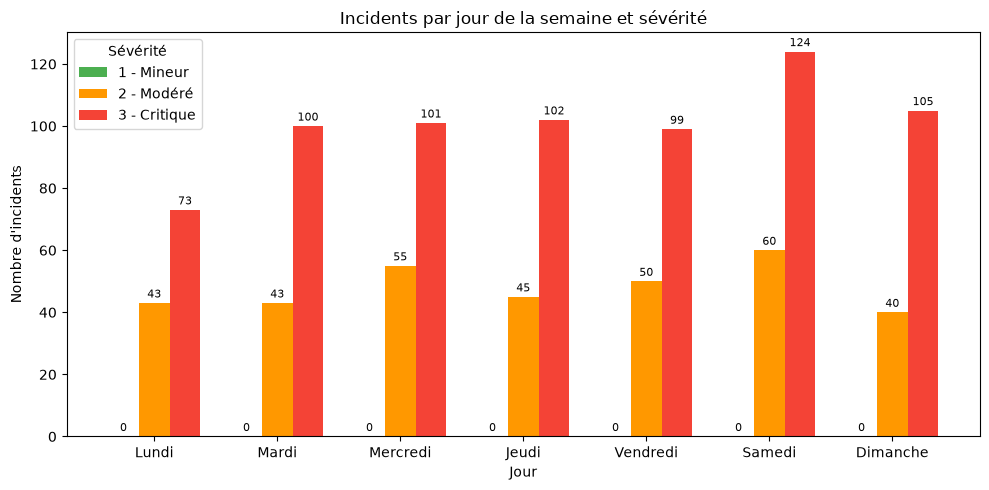

In [5]:
fig = incident_report_per_day_and_severity(df)
plt.show()

~~Bof bof la lisibilité sur les jours (1 colonne pour chaque jour de l'année...)~~ => mieux avec un groupement par jour

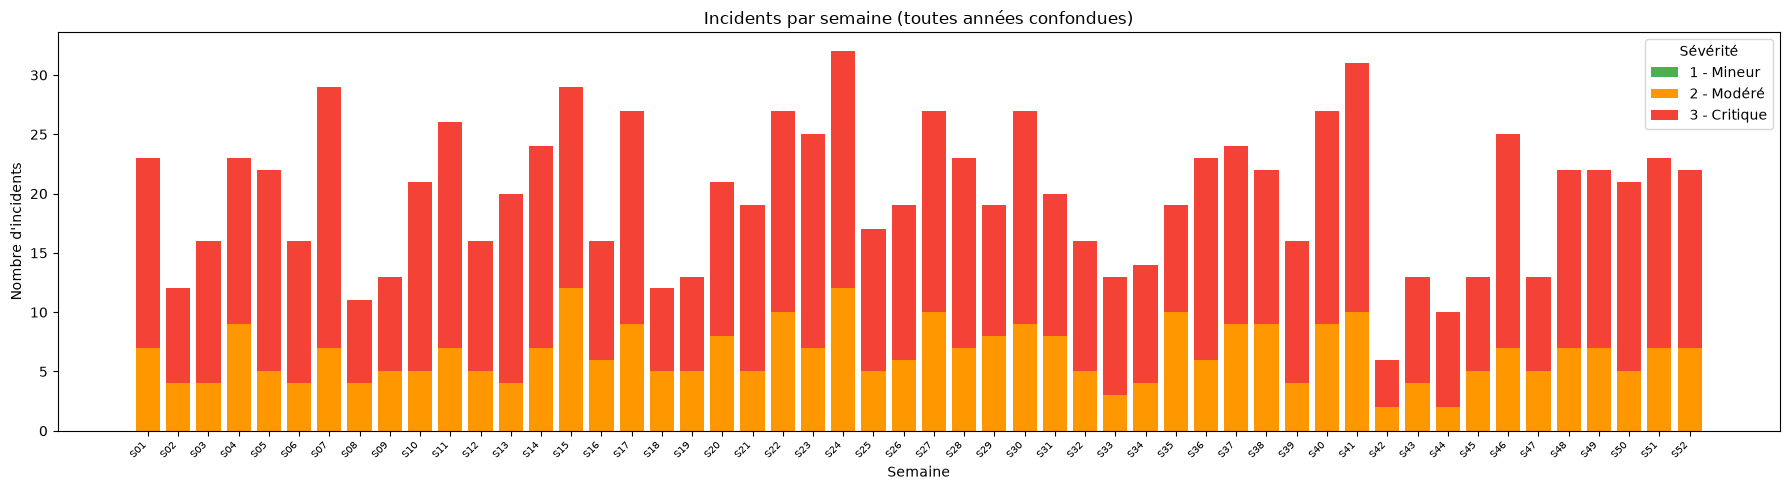

In [6]:
fig = incident_report_per_week_and_severity(df)
plt.show()

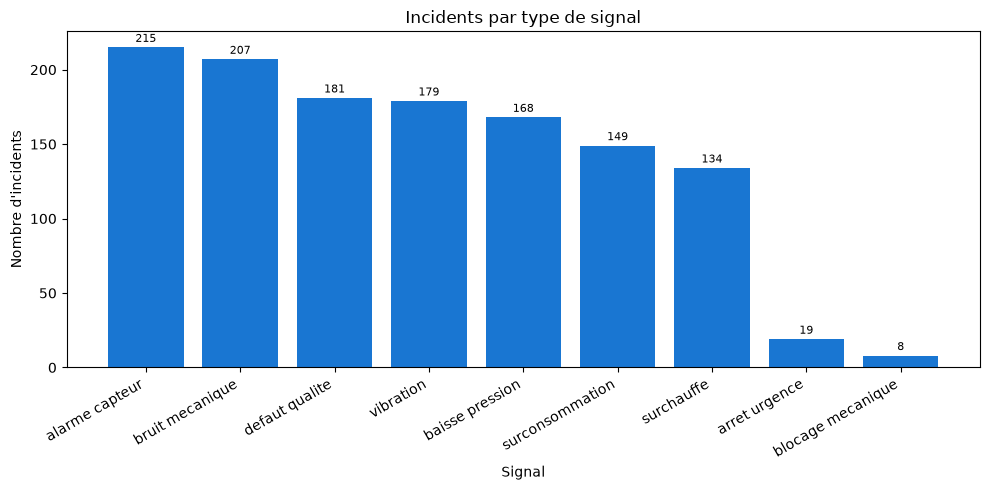

In [7]:
fig = incident_report_per_signal(df)
plt.show()

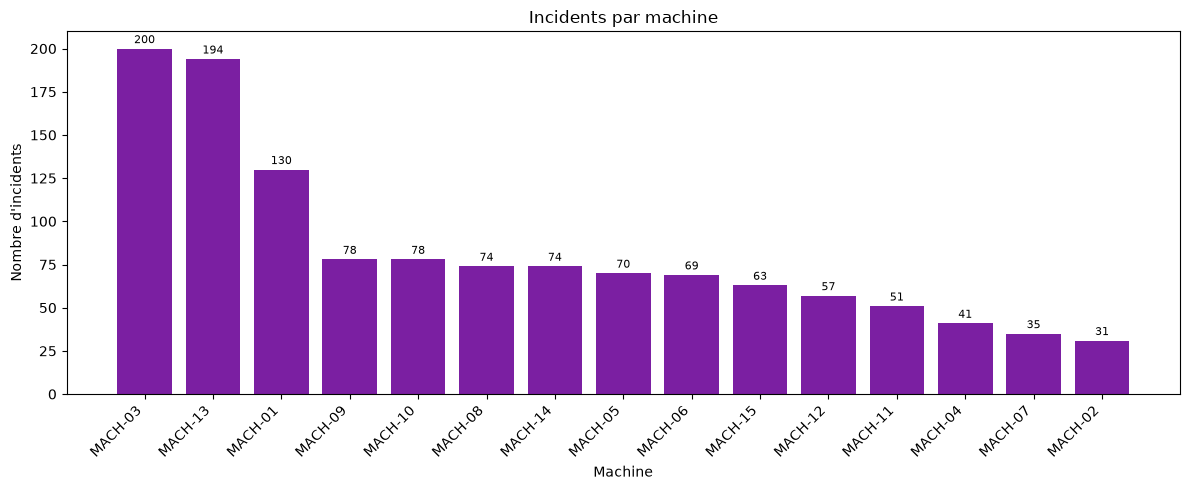

In [8]:
fig = incident_report_per_machine(df)
plt.show()

In [9]:
df = compute_confidence_score(df)
df[["incident_id", "confidence_score"]].head(10)

,incident_id,confidence_score
0,INC-000001,1.0
1,INC-000002,1.0
2,INC-000003,1.0
3,INC-000004,1.0
4,INC-000005,1.0
5,INC-000006,1.0
6,INC-000007,1.0
7,INC-000008,1.0
8,INC-000009,1.0
9,INC-000010,1.0


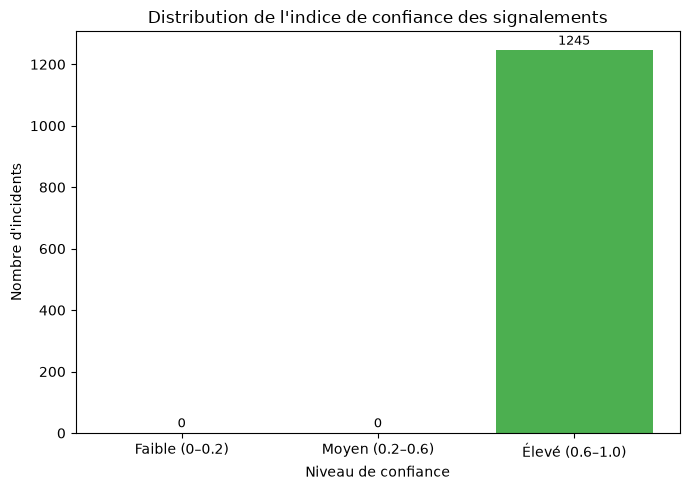

In [10]:
fig = incident_report_confidence(df)
plt.show()

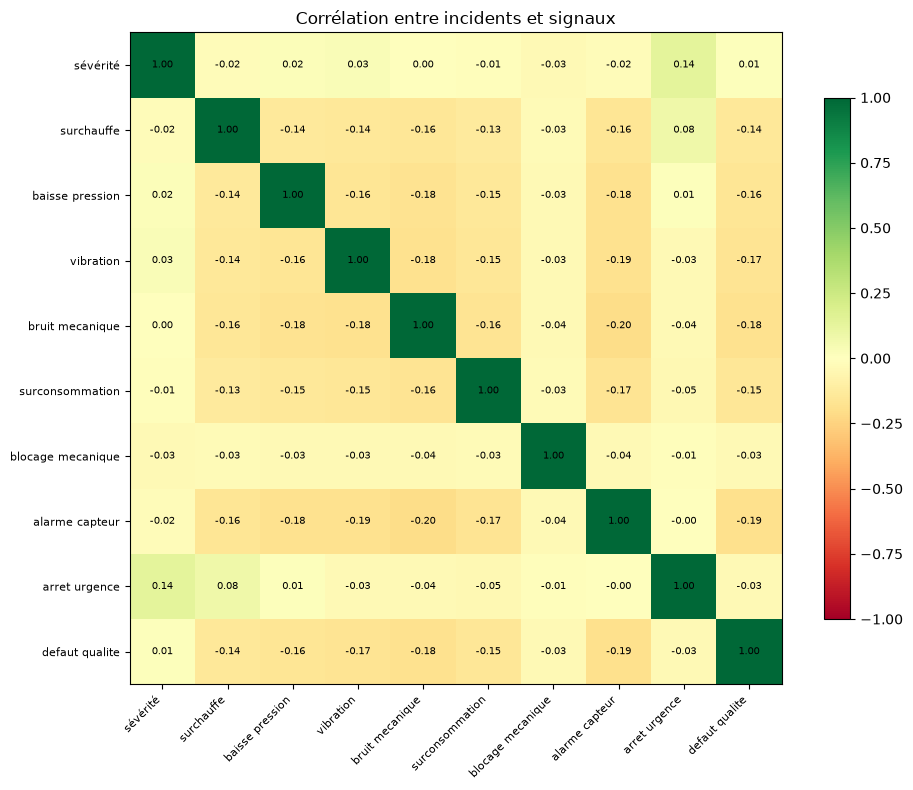

In [11]:
fig = incident_report_signal_correlation(df)
plt.show()

Listing des données manquantes

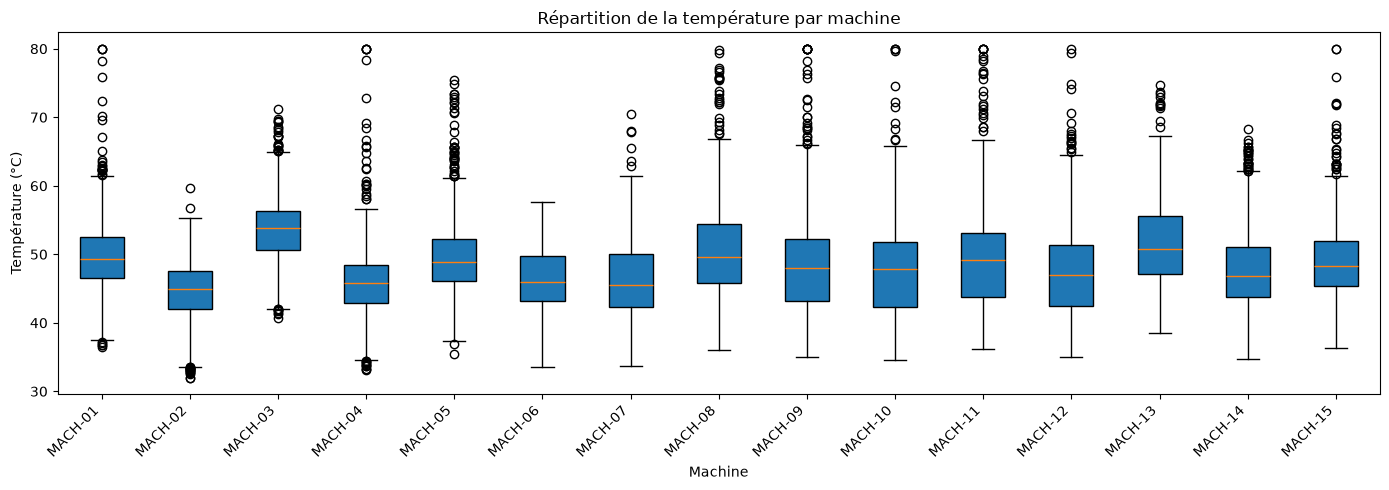

In [12]:
df_tel = load_telemetry("data/telemetry.csv")
fig = telemetry_report_temperature_per_machine(df_tel)
plt.show()

In [13]:
list_missing_telemetry(df_tel, df)

,machine_id,colonne,manquants,total,pct,manquants_h1
0,MACH-01,pressure_bar,66,9033,0.7,1
1,MACH-01,rotation_mean_rpm,77,9033,0.9,0
2,MACH-01,temperature_c,44,9033,0.5,0
3,MACH-02,pressure_bar,43,9042,0.5,1
4,MACH-02,rotation_mean_rpm,53,9042,0.6,0
5,MACH-02,temperature_c,75,9042,0.8,0
6,MACH-03,pressure_bar,52,9054,0.6,0
7,MACH-03,rotation_mean_rpm,80,9054,0.9,0
8,MACH-03,temperature_c,55,9054,0.6,0
9,MACH-04,pressure_bar,53,9042,0.6,0


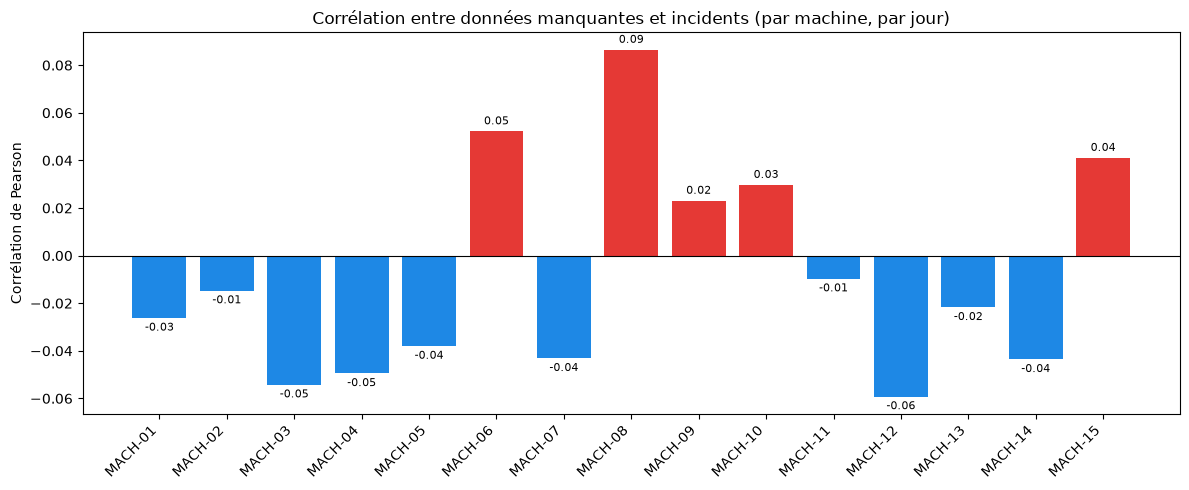

In [14]:
fig = missing_telemetry_incident_correlation(df_tel, df)
plt.show()

Outliers en Z-Score

In [17]:
df_anomalies = detect_telemetry_anomalies(df_tel)
df_anomalies

,machine_id,date,colonne,valeur,z_score
0,MACH-01,2025-06-16 22:00:00,pressure_bar,191.276,-4.03
1,MACH-01,2025-06-16 23:00:00,pressure_bar,189.239,-5.02
2,MACH-01,2025-06-17 00:00:00,pressure_bar,186.456,-6.38
3,MACH-01,2025-08-15 16:00:00,pressure_bar,190.200,-4.55
4,MACH-01,2025-08-15 17:00:00,pressure_bar,190.222,-4.54
...,...,...,...,...,...
2803,MACH-15,2026-04-08 07:00:00,voltage_mean_v,234.180,6.44
2804,MACH-15,2026-04-08 08:00:00,voltage_mean_v,235.340,7.41
2805,MACH-15,2026-04-08 09:00:00,voltage_mean_v,235.370,7.44
2806,MACH-15,2026-04-08 10:00:00,voltage_mean_v,235.050,7.17


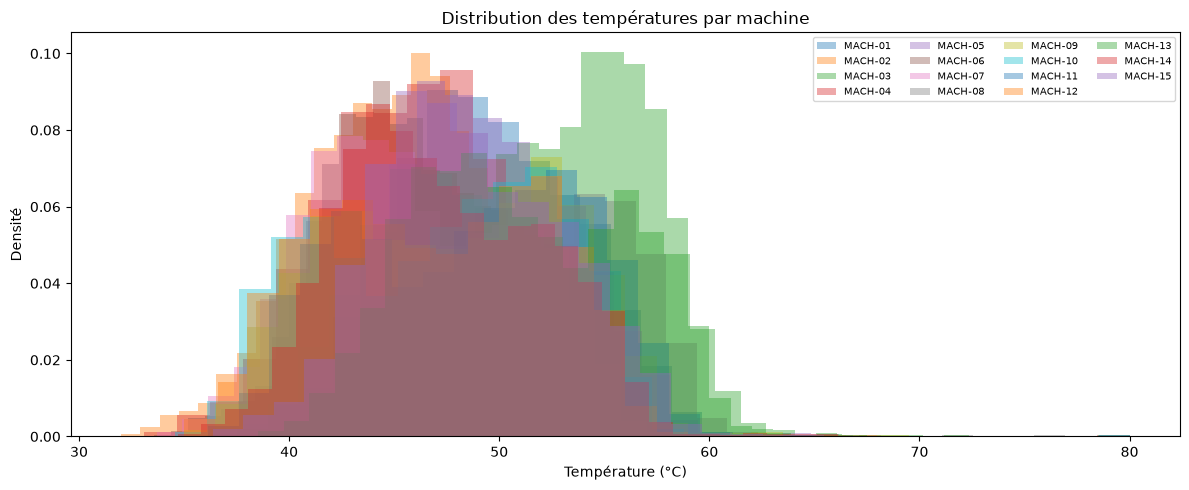

In [18]:
fig = telemetry_report_temperature_distribution(df_tel)
plt.show()

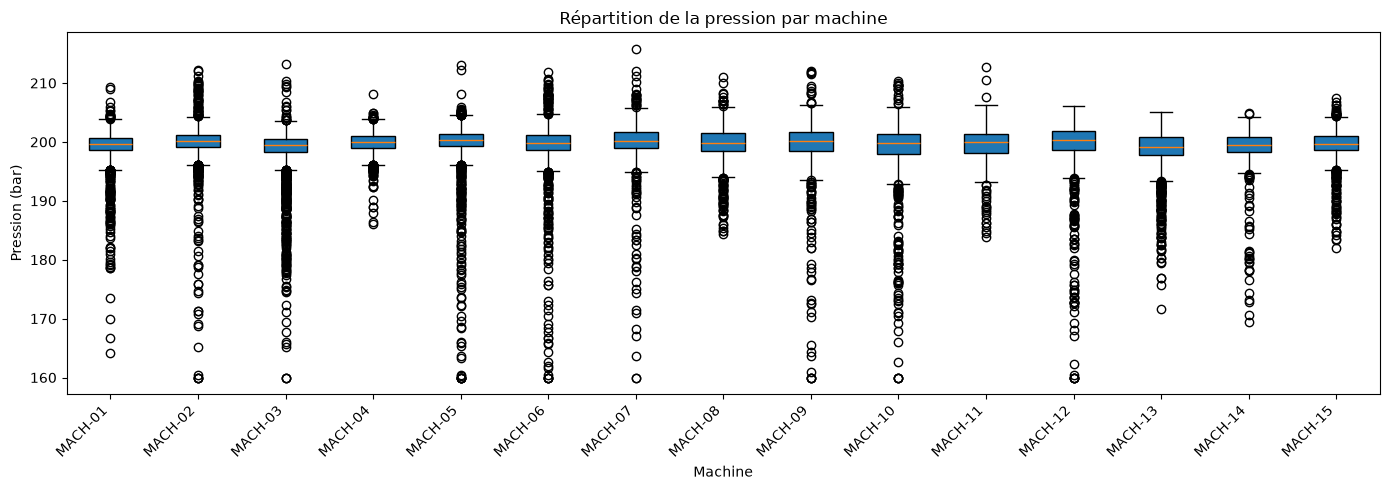

In [19]:
fig = telemetry_report_pressure_per_machine(df_tel)
plt.show()

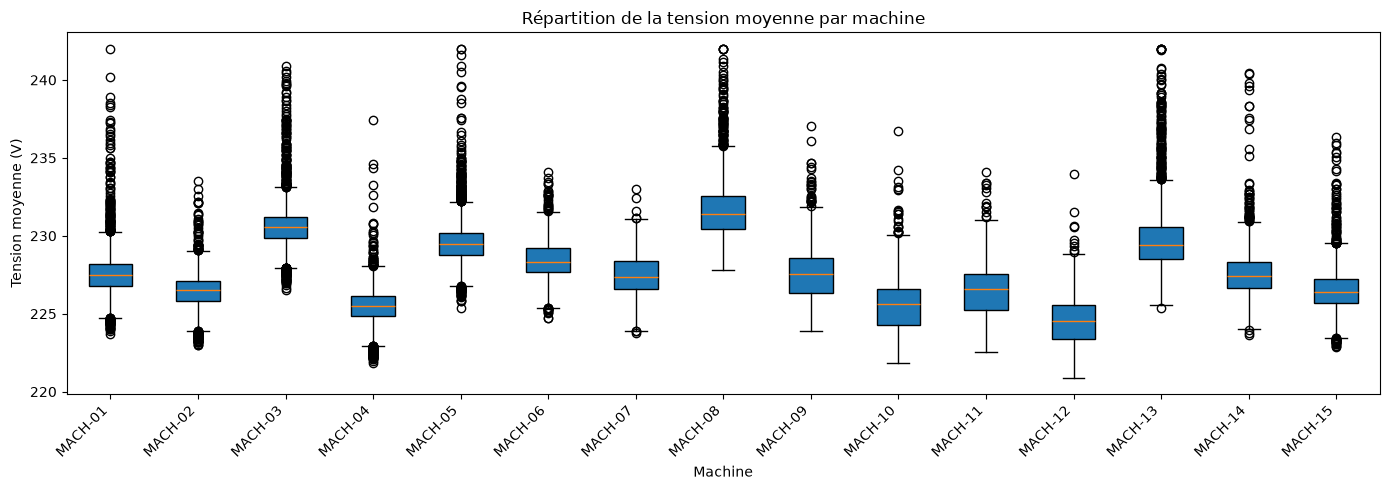

In [20]:
fig = telemetry_report_voltage_per_machine(df_tel)
plt.show()

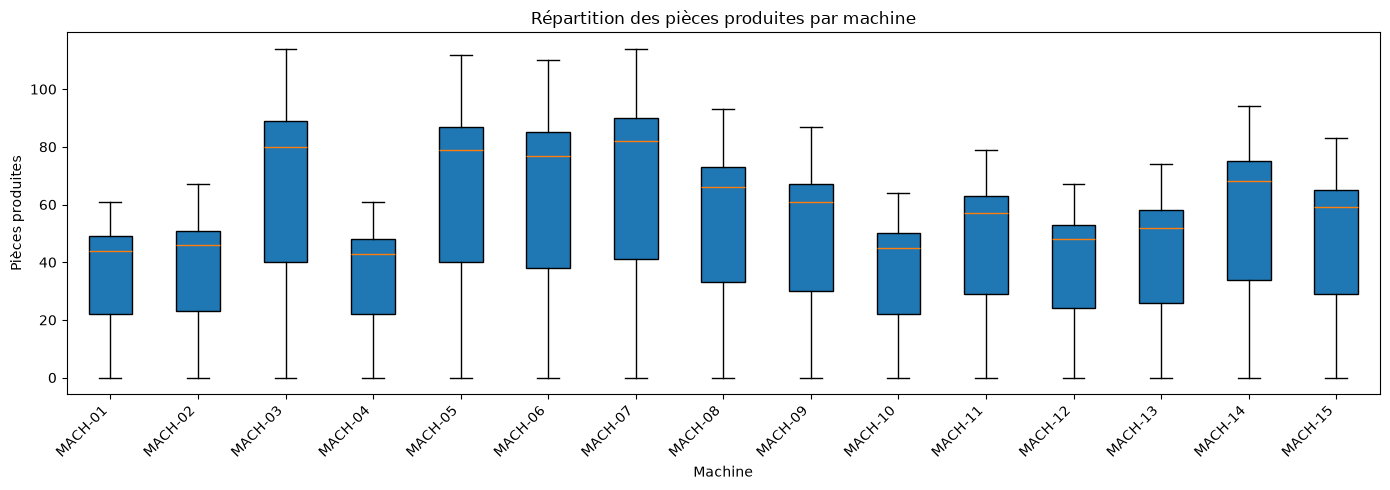

In [21]:
fig = telemetry_report_pieces_per_machine(df_tel)
plt.show()

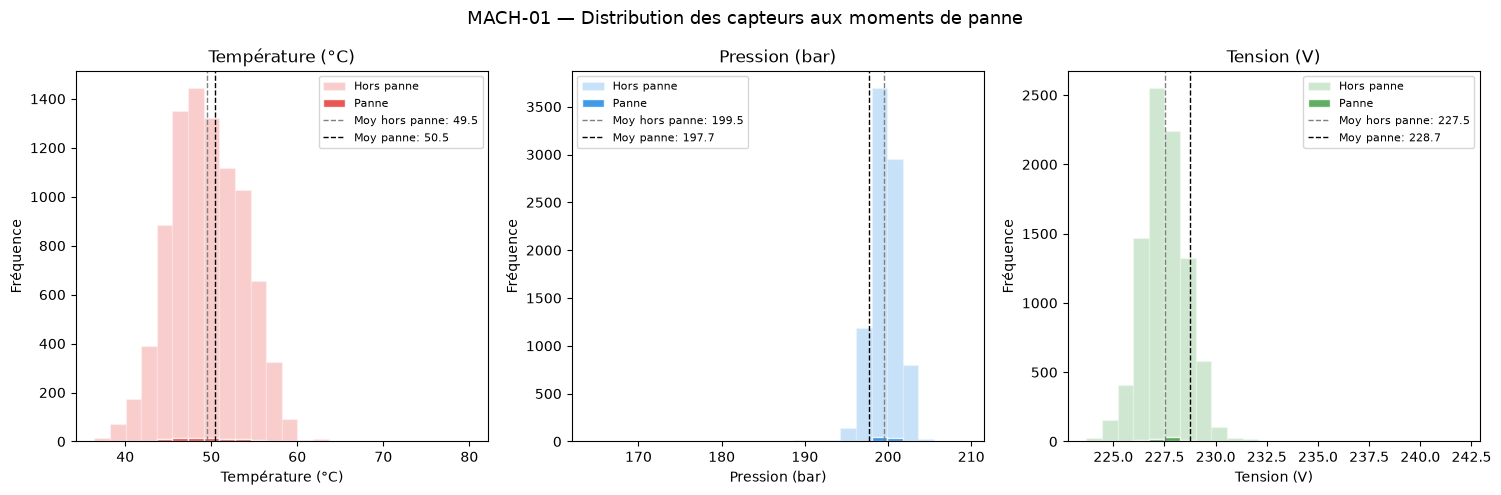

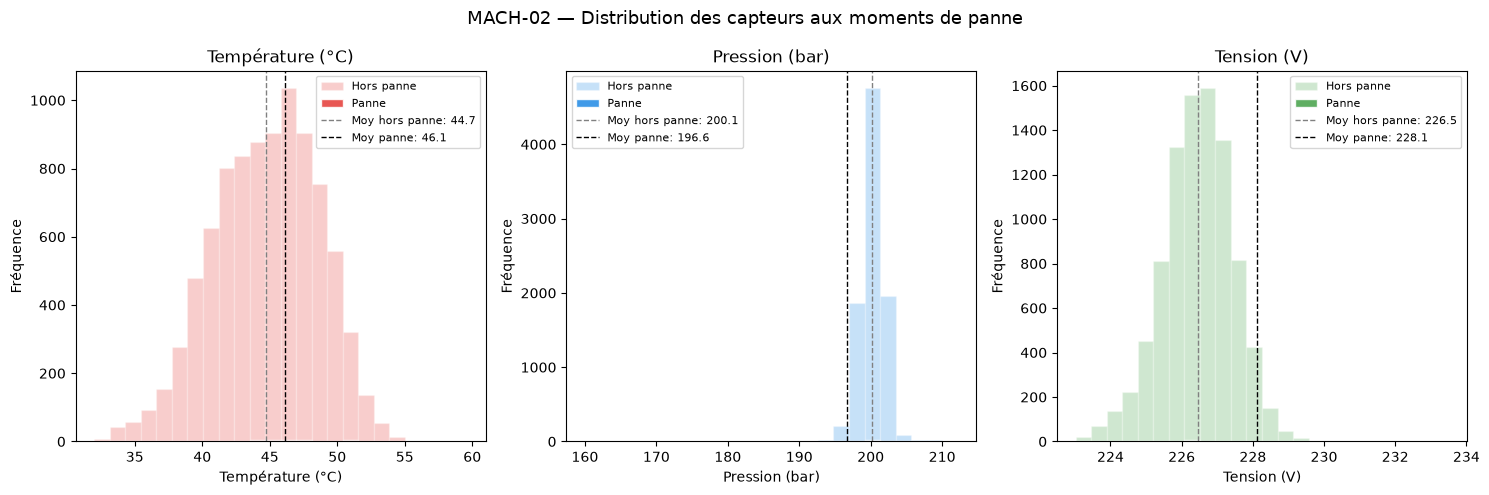

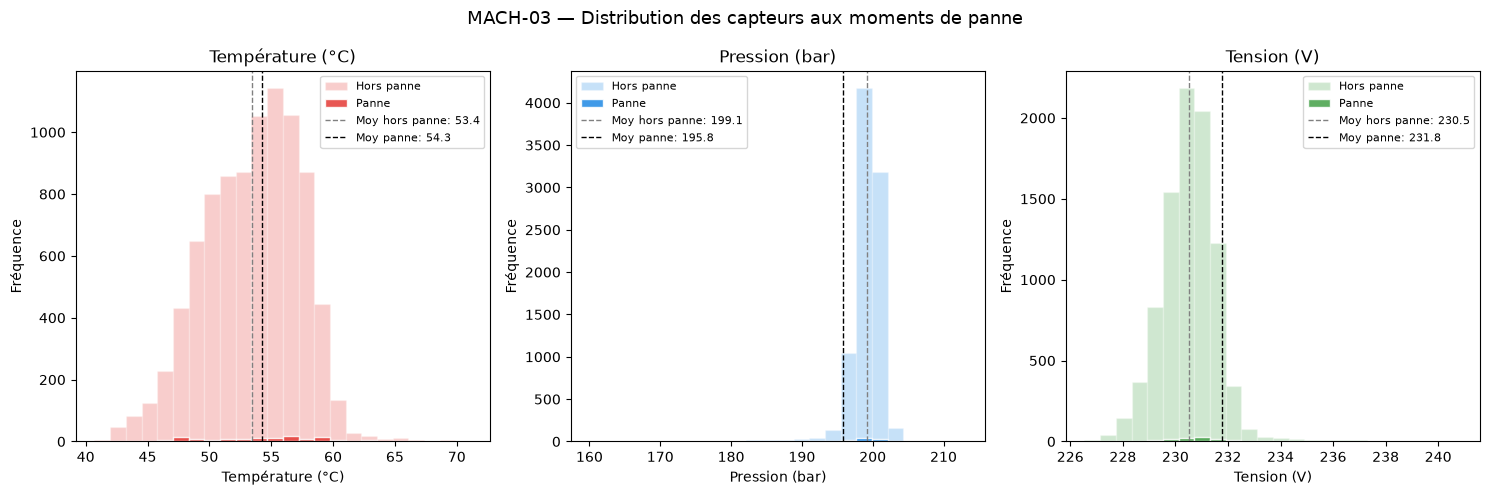

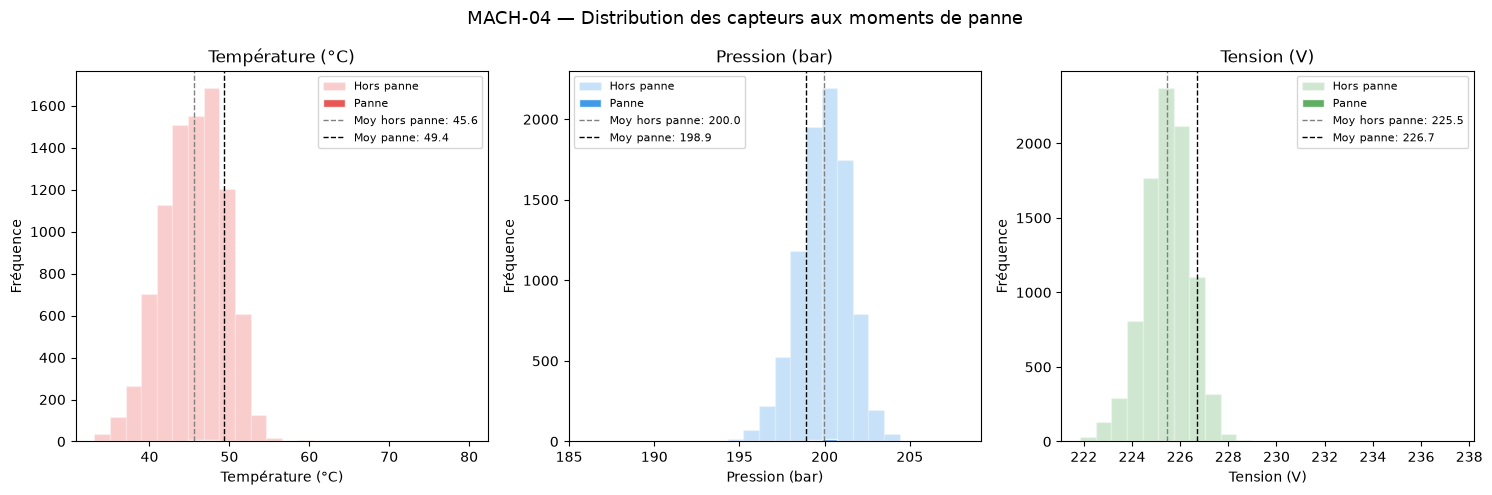

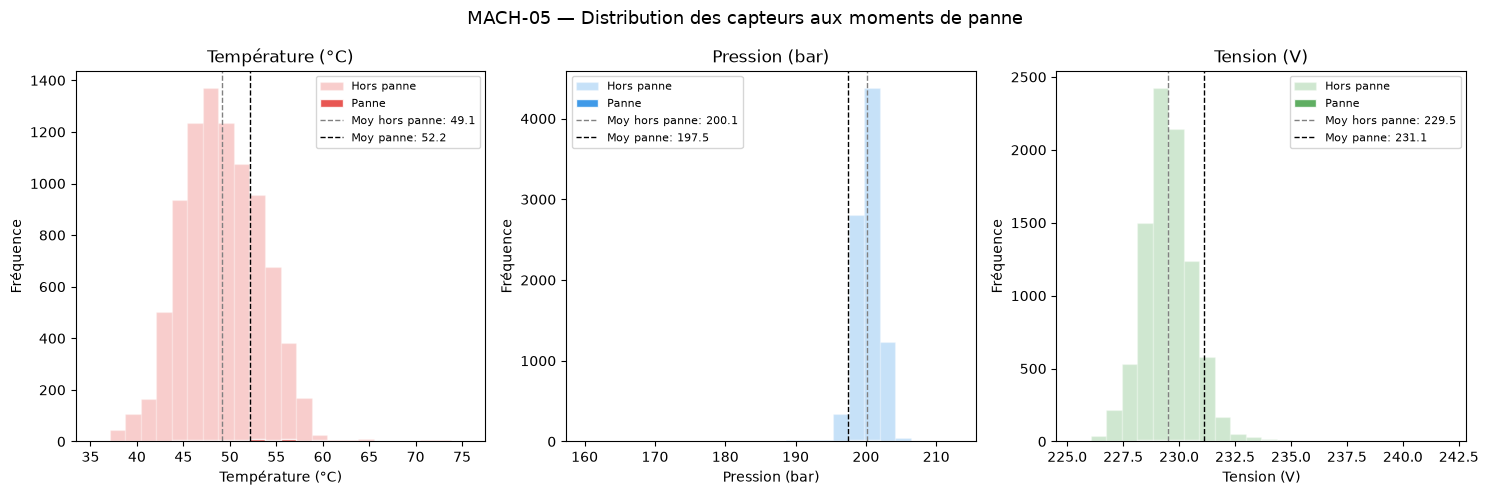

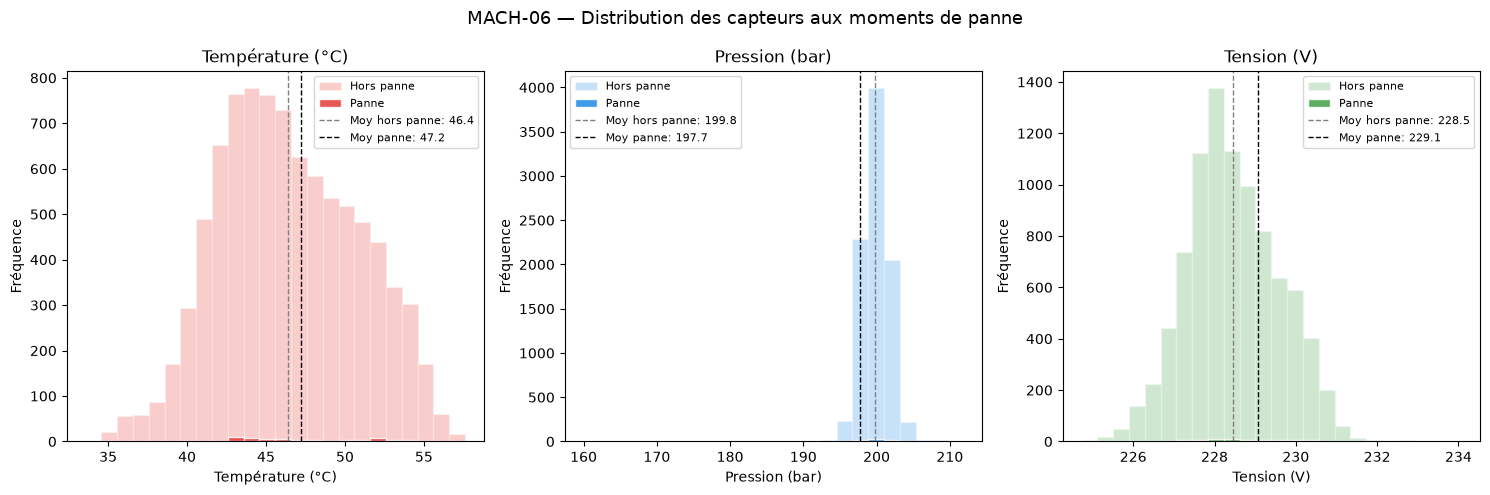

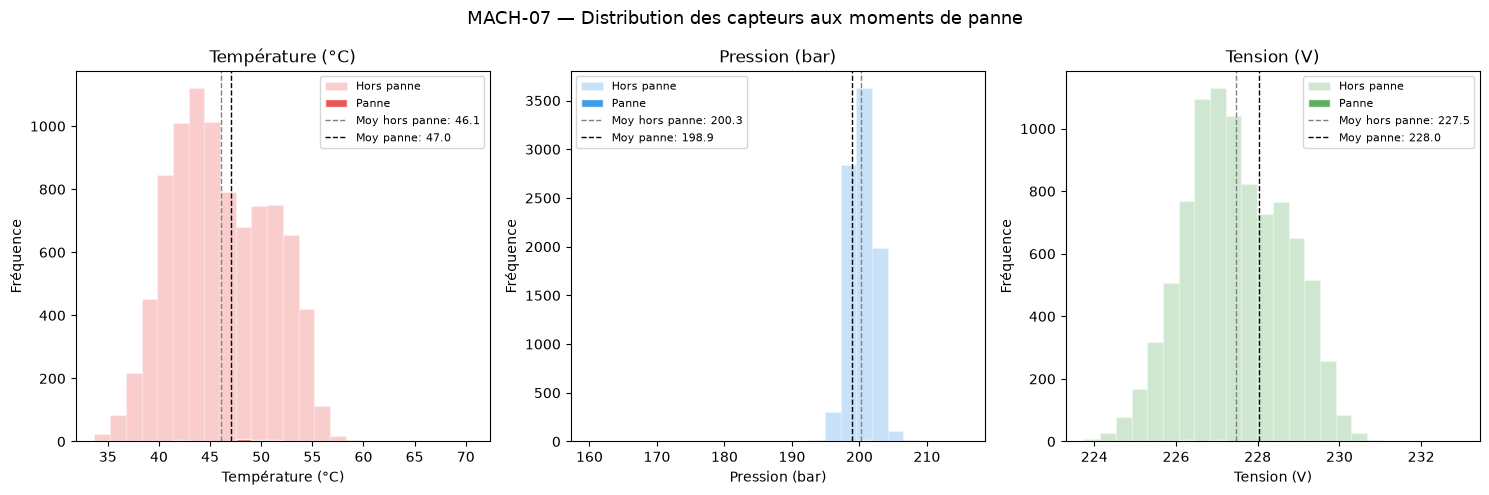

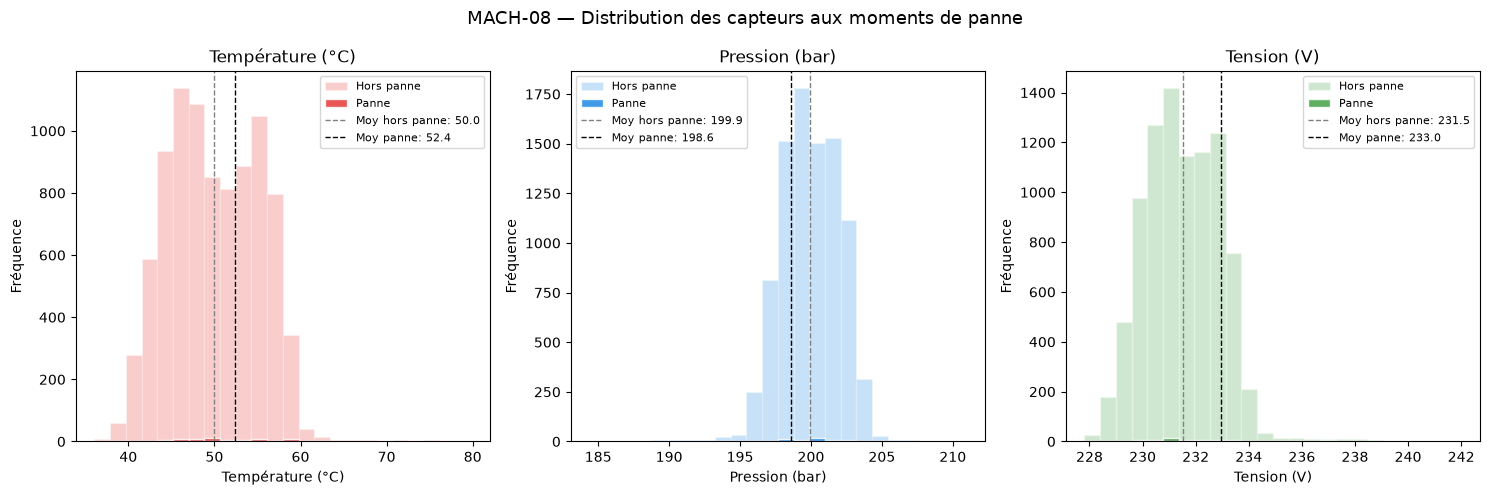

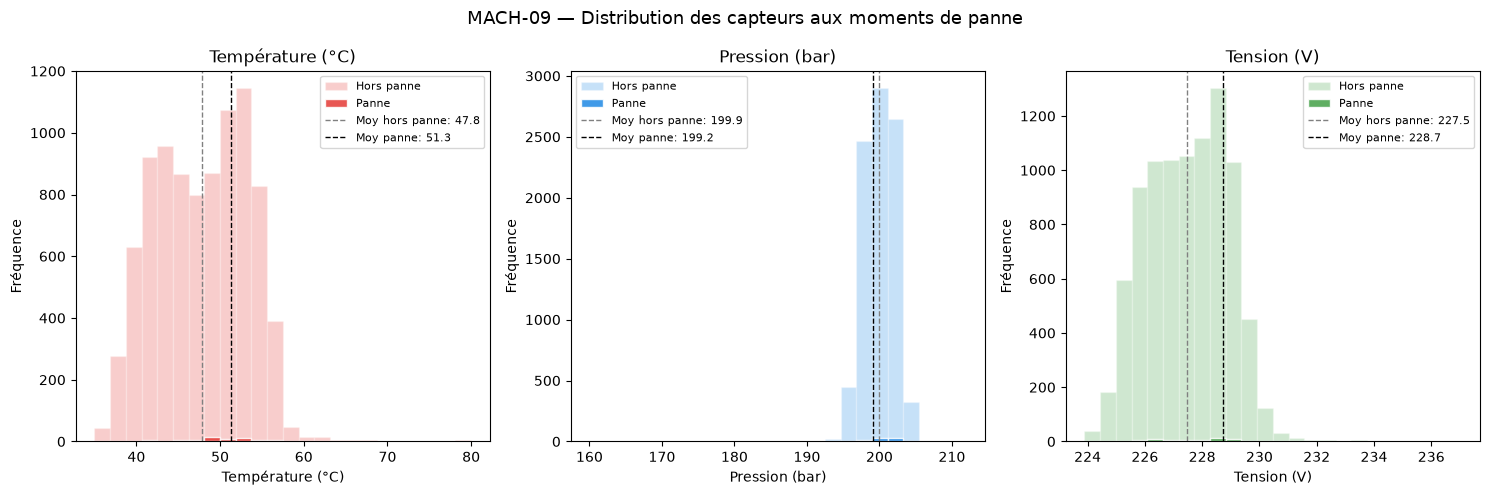

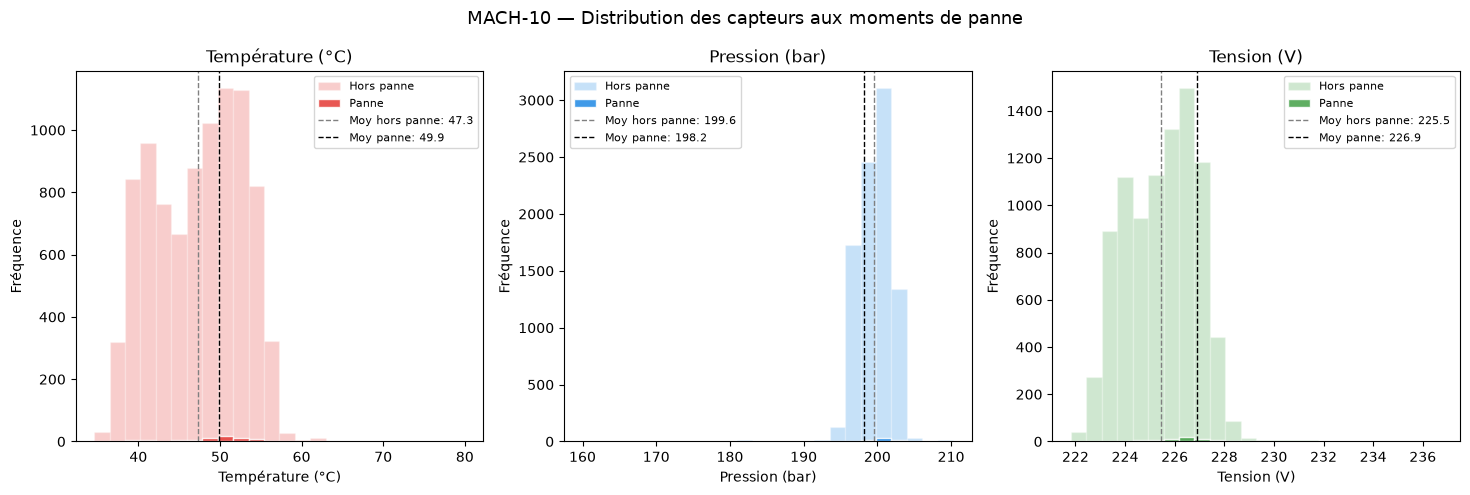

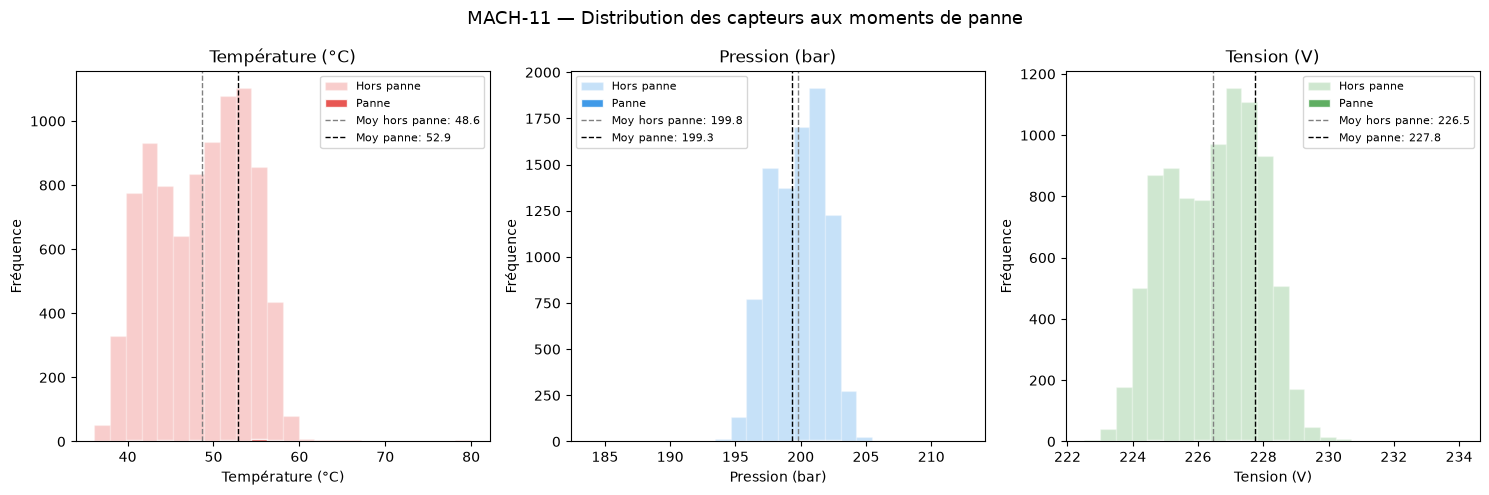

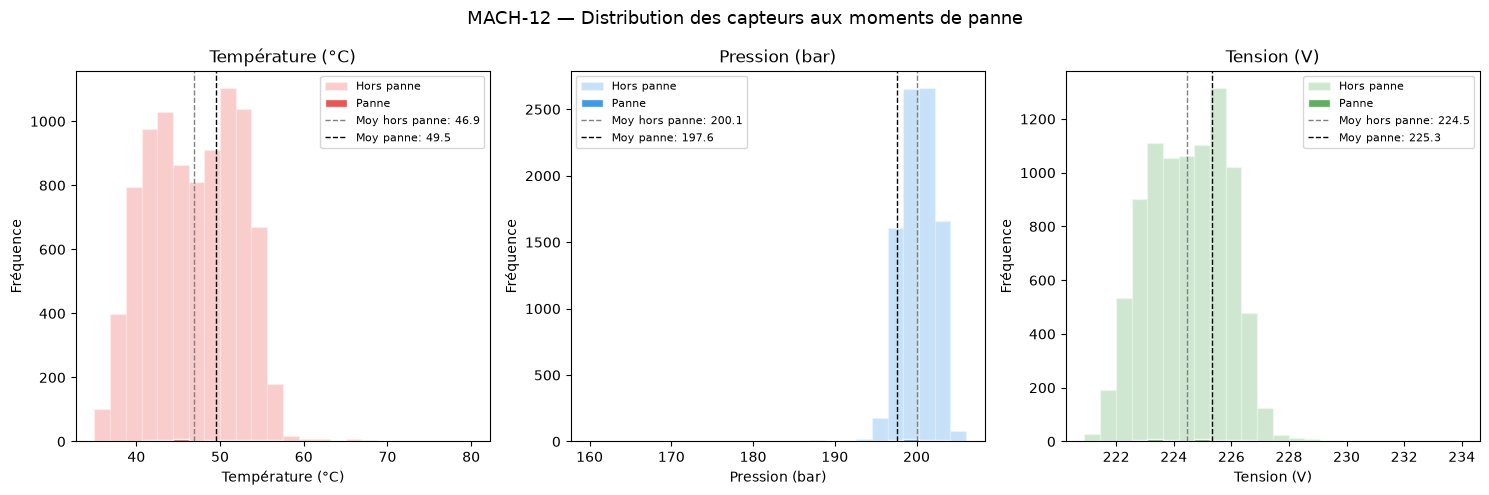

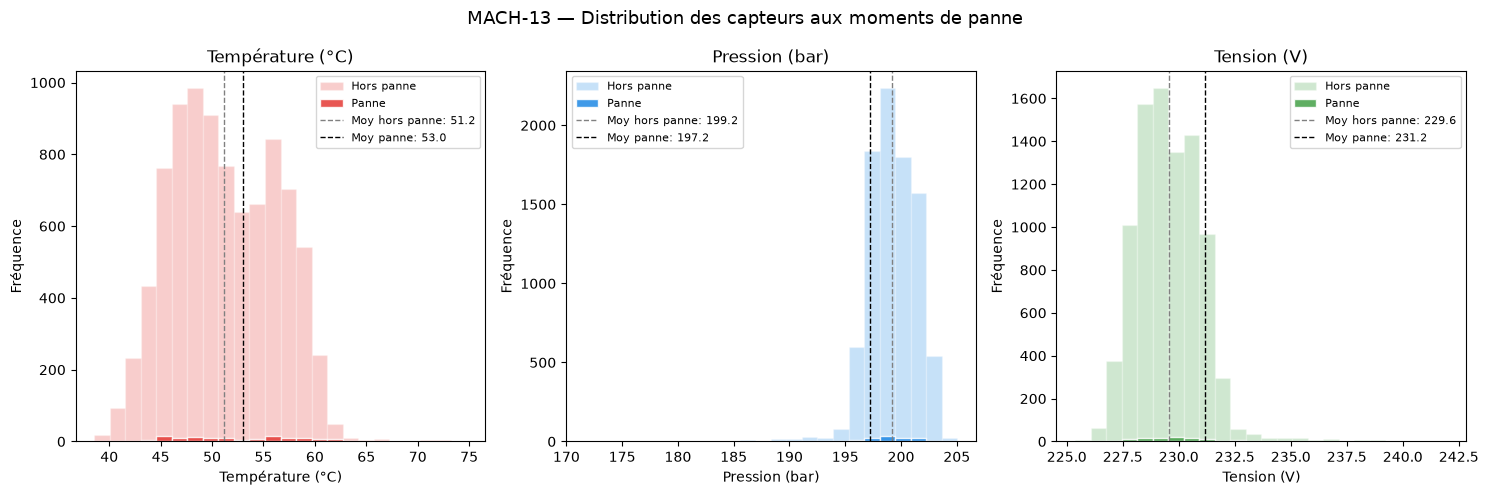

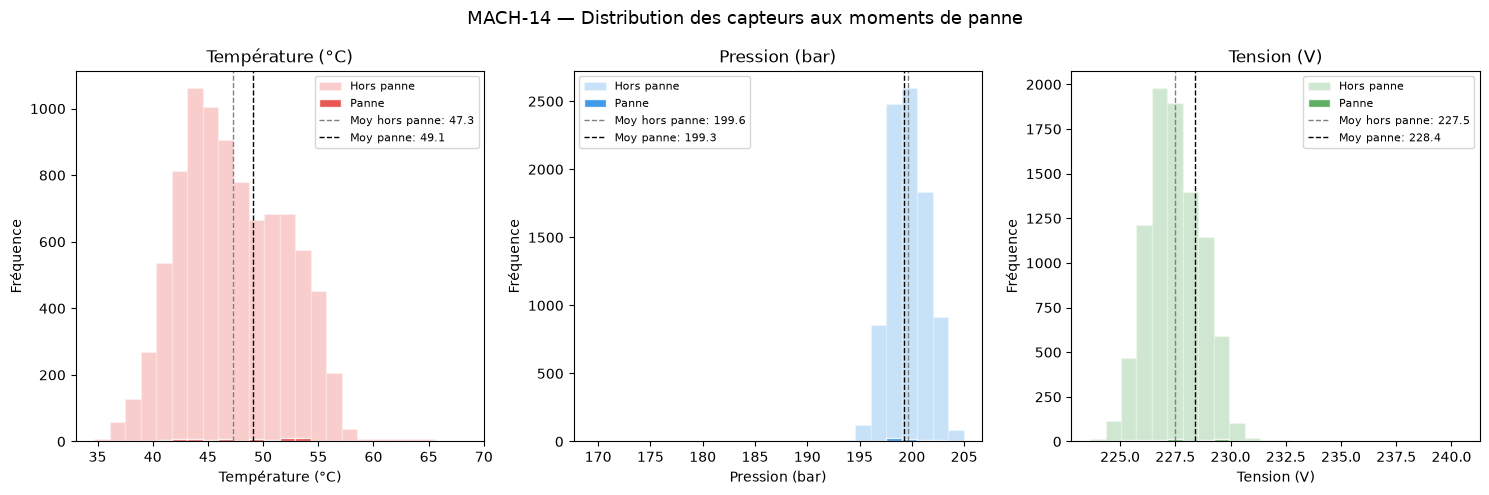

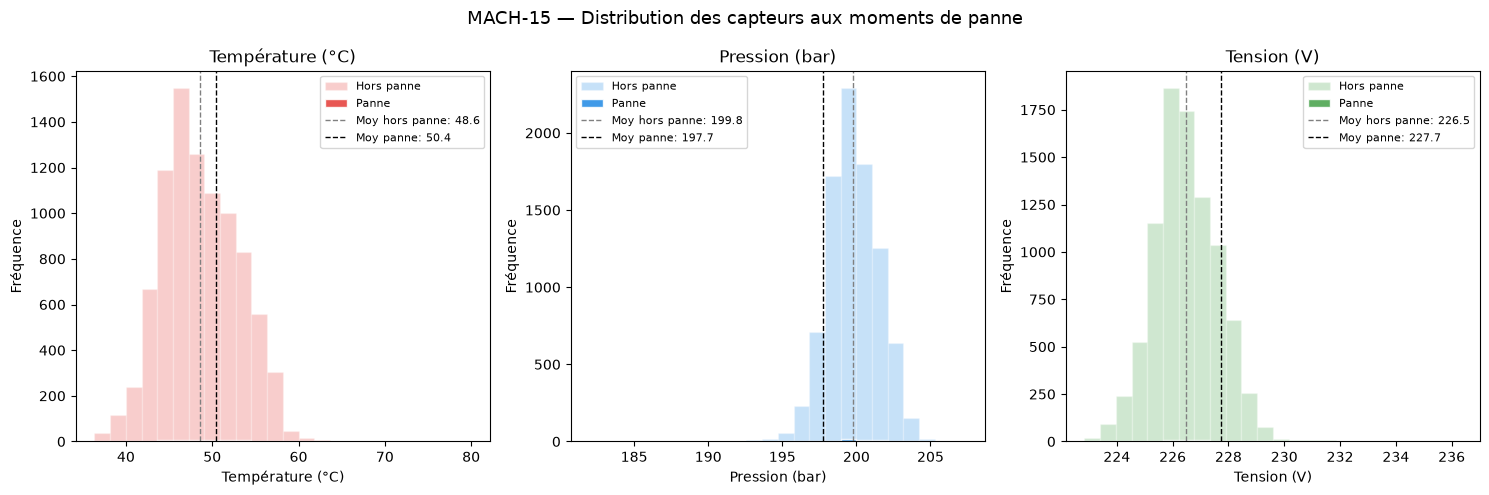

In [22]:
for machine in sorted(df_tel["machine_id"].unique()):
    fig = telemetry_report_failure_distributions(df_tel, df, machine)
    plt.show()

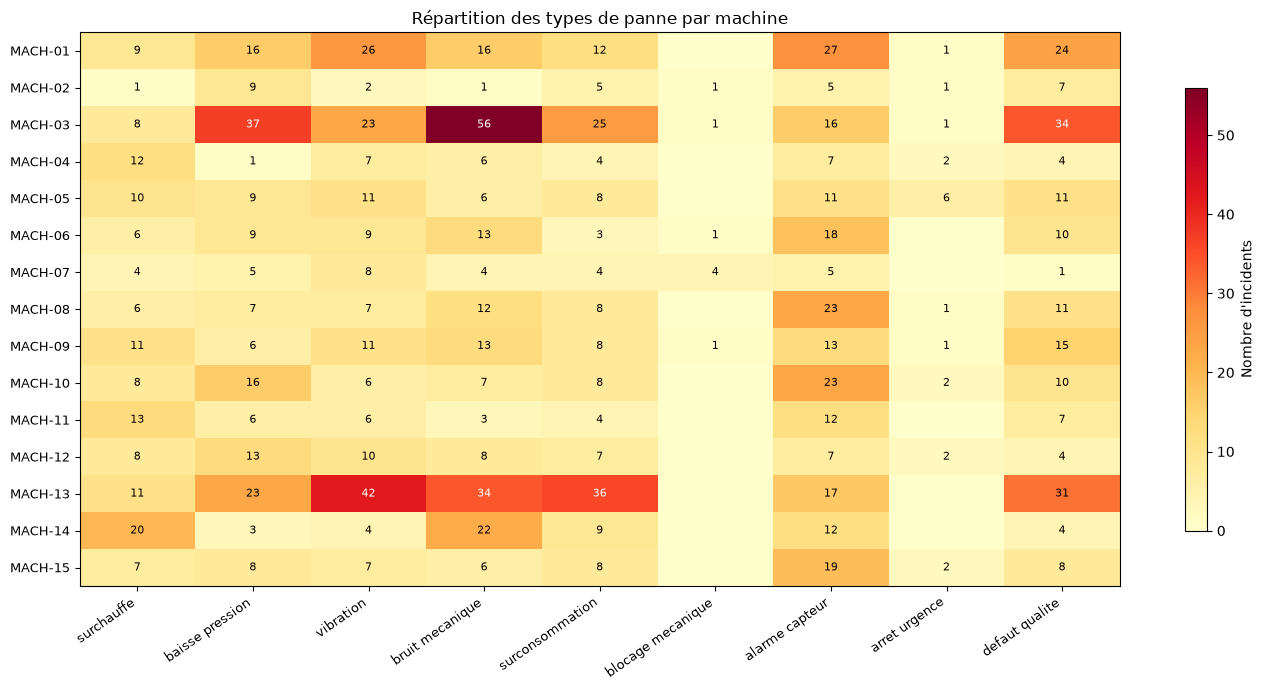

In [23]:
fig = incident_report_type_per_machine(df)
plt.show()

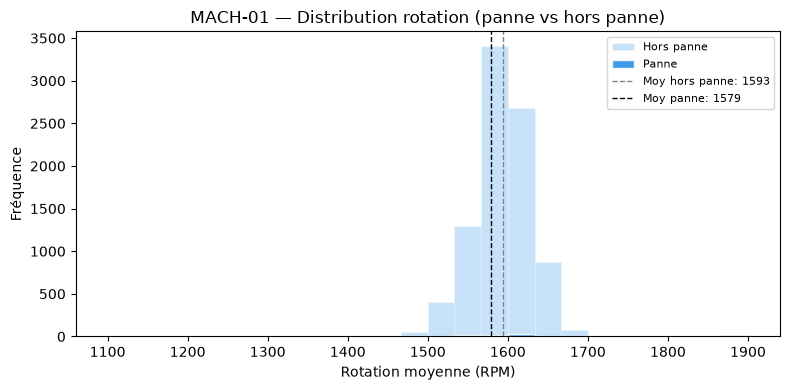

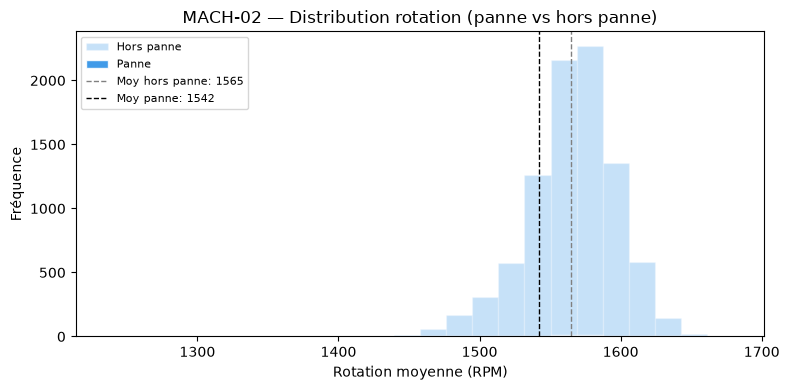

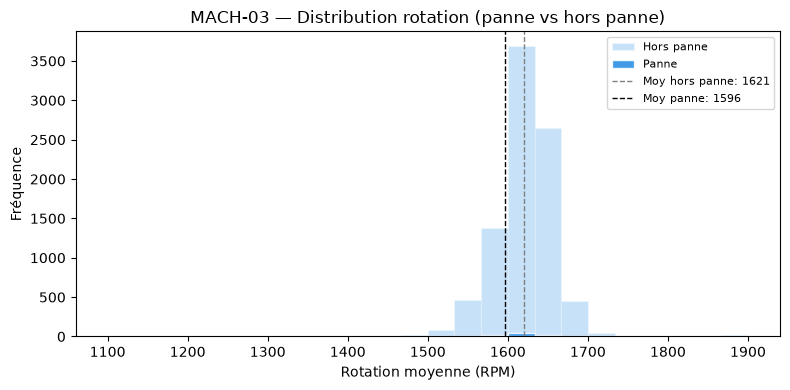

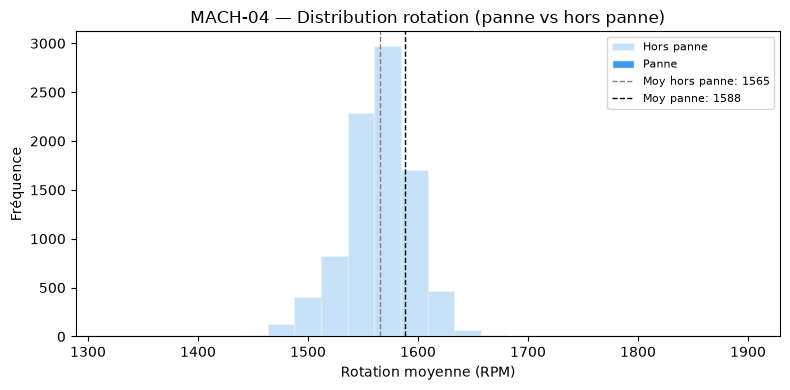

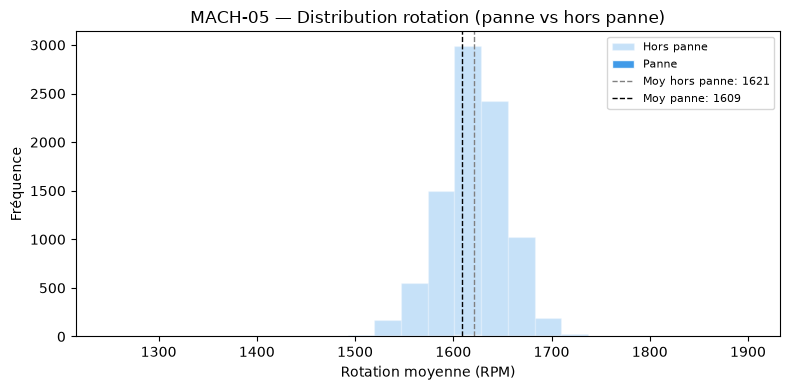

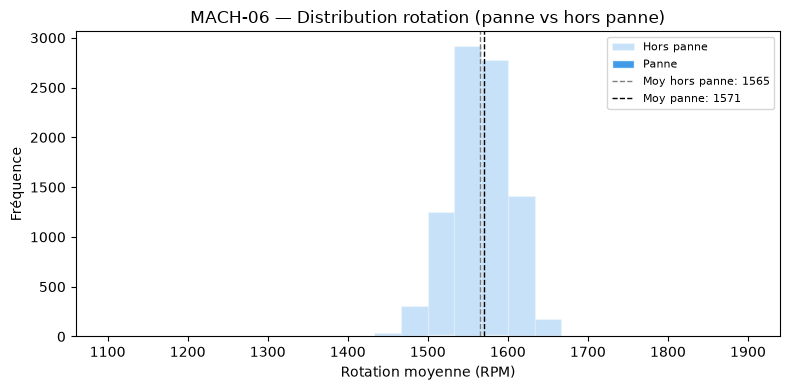

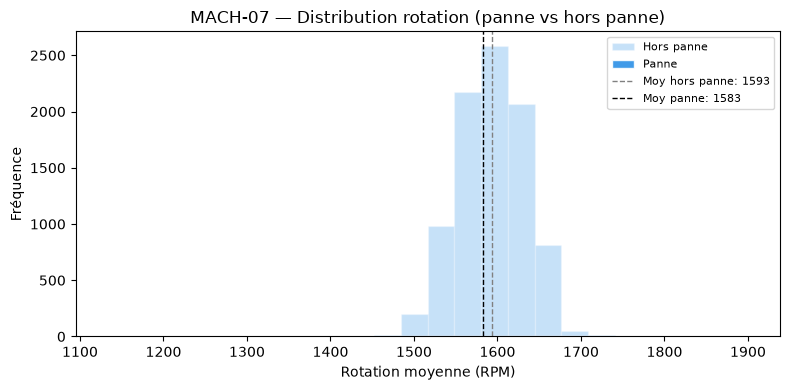

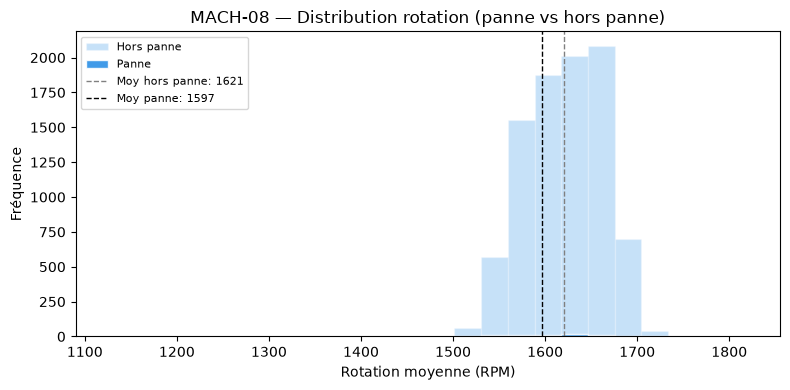

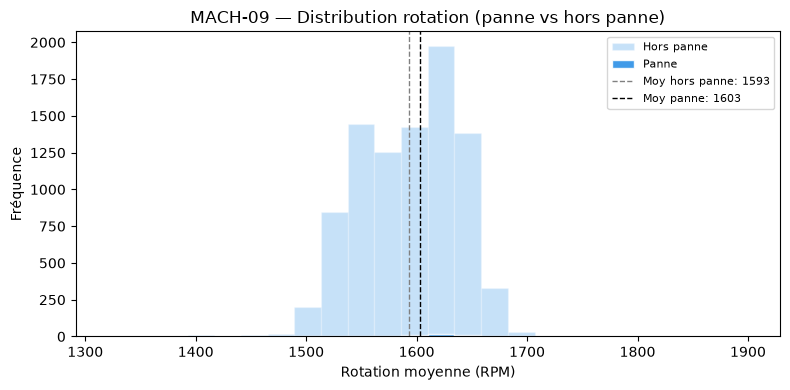

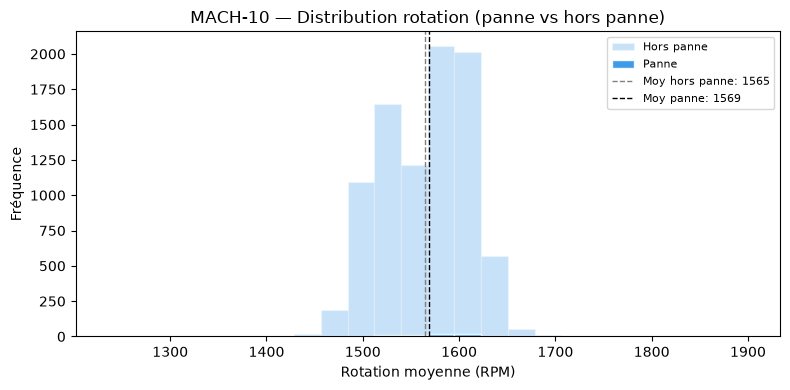

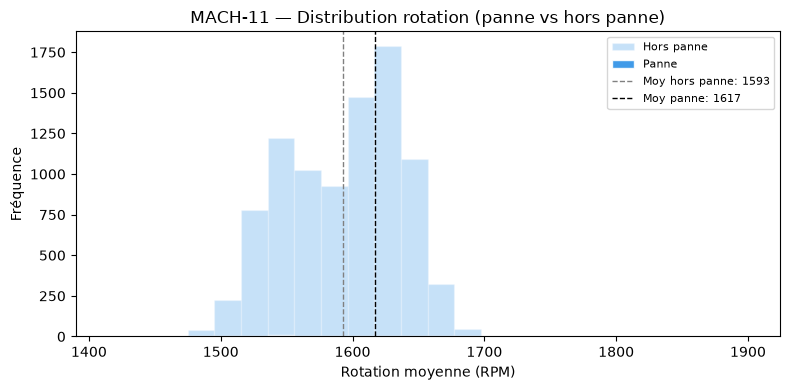

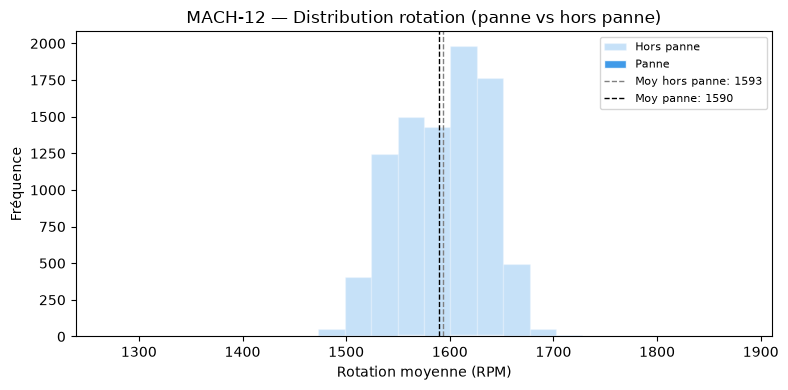

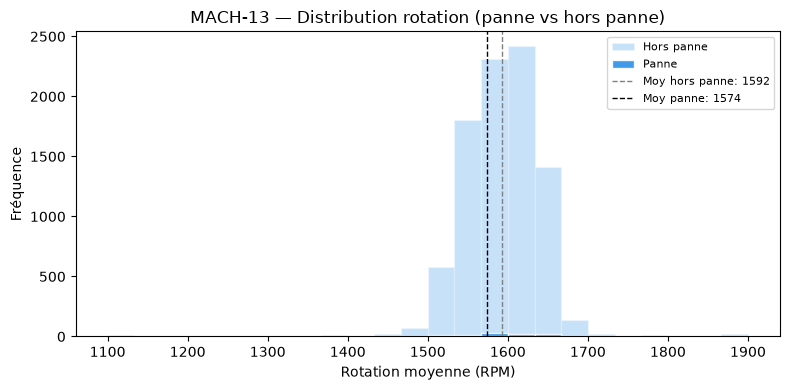

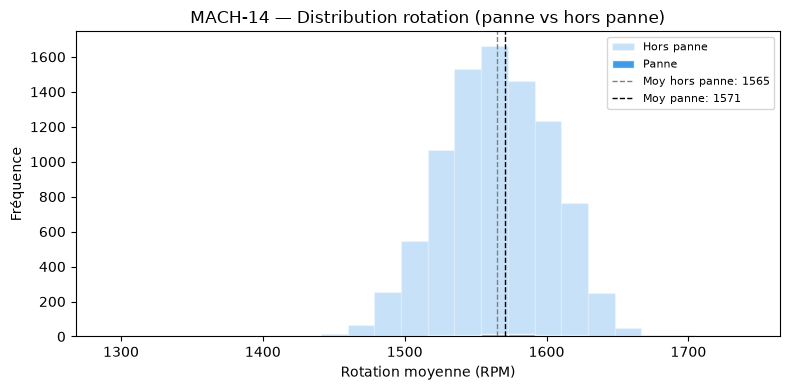

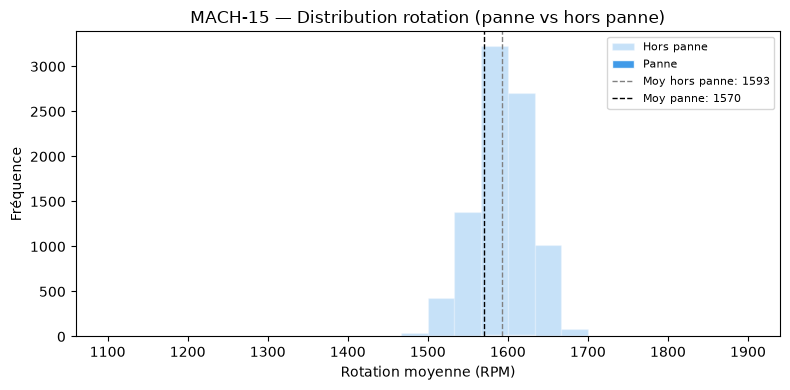

In [24]:
for machine in sorted(df_tel["machine_id"].unique()):
    fig = telemetry_report_rotation_failure_per_machine(df_tel, df, machine)
    plt.show()